# 04 — Model: Overheating Risk

Two layers:

1. **Weighted index** (explainable, documented weights) → produces the 0–100 score and 4 tiers.
2. **Random Forest** trained against the index-derived tier → used for SHAP-style feature attribution.

The RF does *not* validate the index — that would be circular. Its job is interpretability and to serve as a downstream API for the app.

In [1]:
import sys; sys.path.insert(0, '..')
from src.risk_model import build_feature_table, train_classifier, FEATURES, WEIGHTS
df = build_feature_table()
df[['lad_name','overheating_risk_score','risk_tier']].sort_values('overheating_risk_score', ascending=False).head(15)


/usr/local/lib/python3.10/dist-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,lad_name,overheating_risk_score,risk_tier
40,Westminster,64.73,High
37,Tower Hamlets,63.56,High
14,Camden,61.91,High
39,Wandsworth,61.90,High
32,Newham,61.61,High
19,Hackney,61.32,High
21,Haringey,61.21,High
12,Brent,61.11,High
29,Lambeth,60.81,High
26,Islington,60.76,High


## Train

In [2]:
metrics = train_classifier(df)
print(f"train acc: {metrics['train_accuracy']:.3f}  test acc: {metrics['test_accuracy']:.3f}")
print(f"n_train={metrics['n_train']} n_test={metrics['n_test']}")


train acc: 1.000  test acc: 0.909
n_train=30 n_test=11


## Feature importances

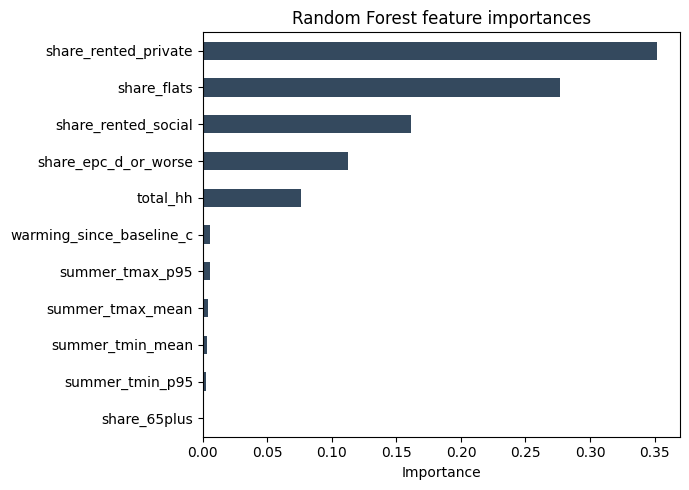

In [3]:
import pandas as pd, matplotlib.pyplot as plt
fi = pd.Series(metrics['feature_importances']).sort_values()
fi.plot.barh(figsize=(7,5), color='#34495e')
plt.title('Random Forest feature importances')
plt.xlabel('Importance'); plt.tight_layout()


## SHAP attribution (optional — requires `shap`)
Per-LAD attribution of each feature's contribution to the predicted tier.

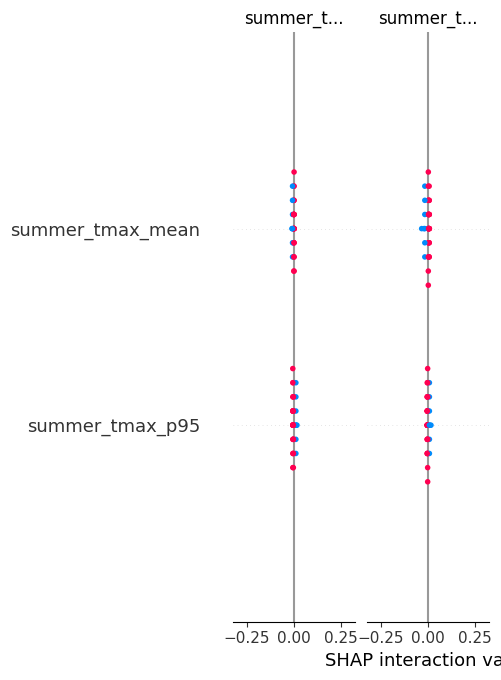

In [4]:
try:
    import shap
    import joblib
    clf = joblib.load('../models/risk_model.pkl')
    X = df[FEATURES].fillna(df[FEATURES].median())
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(X)
    shap.summary_plot(sv, X, plot_type='bar')
except ImportError:
    print('Install shap to run this cell: pip install shap')
